# 🔐 Environment Variable Checker - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/env-checker/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/env-checker/demo.ipynb)

> *"Deployments fail from missing env vars."*

A tiny pre-flight check: declare which env vars your app needs (and what they
should look like), then validate the real environment **before** you ship. A bad
environment exits non-zero, so CI or your deploy script blocks the release.

**What we cover**
1. Write a schema
2. Parse it
3. Check a broken environment
4. Check a good environment
5. Visualize the pass/fail breakdown


## Step 1 - Declare what the app needs

Schema format: `NAME=required|optional[:regex]  # comment`. Regex lets you assert
shape, not just presence (`PORT` must be digits, `DATABASE_URL` must be Postgres).


In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from typing import Dict, List, Optional

SCHEMA = """# Deploy requirements
DATABASE_URL=required:^postgres://     # primary database
API_KEY=required                        # third-party API key
PORT=optional:^\\d+$                     # web port, digits only
DEBUG=optional:^(true|false)$           # feature flag
"""
print(SCHEMA)

# Deploy requirements
DATABASE_URL=required:^postgres://     # primary database
API_KEY=required                        # third-party API key
PORT=optional:^\d+$                     # web port, digits only
DEBUG=optional:^(true|false)$           # feature flag



## Step 2 - Parse the schema

Malformed lines are skipped, never fatal - a typo in the schema shouldn't crash
the check.


In [2]:
@dataclass
class VarSpec:
    name: str
    required: bool
    pattern: Optional[str] = None
    comment: str = ""

def parse_schema(text: str) -> List[VarSpec]:
    specs: List[VarSpec] = []
    for raw in text.splitlines():
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        comment = ""
        if "#" in line:
            line, comment = line.split("#", 1); line, comment = line.strip(), comment.strip()
        if "=" not in line:
            continue
        name, rule = line.split("=", 1); name, rule = name.strip(), rule.strip()
        pattern = None
        if ":" in rule:
            kind, pattern = rule.split(":", 1); kind = kind.strip(); pattern = pattern.strip()
        else:
            kind = rule
        specs.append(VarSpec(name, kind.lower() == "required", pattern or None, comment))
    return specs

specs = parse_schema(SCHEMA)
for s in specs:
    print(f"{s.name:14s} required={s.required!s:5s} pattern={s.pattern}")

DATABASE_URL   required=True  pattern=^postgres://
API_KEY        required=True  pattern=None
PORT           required=False pattern=^\d+$
DEBUG          required=False pattern=^(true|false)$


## Step 3 - Check a broken environment

Wrong DB scheme, a non-numeric port, and a missing API key. We catch all three.


In [3]:
def check_env(specs: List[VarSpec], env: Dict[str, str]) -> Dict[str, List[Dict[str, str]]]:
    report = {"missing": [], "invalid": [], "ok": [], "optional_missing": []}
    for spec in specs:
        value = env.get(spec.name)
        present = value is not None and value != ""
        if not present:
            (report["missing"] if spec.required else report["optional_missing"]).append(
                {"name": spec.name, "reason": "required but not set" if spec.required else ""})
            continue
        if spec.pattern is not None and not re.search(spec.pattern, value):
            report["invalid"].append({"name": spec.name, "reason": f"does not match /{spec.pattern}/"})
            continue
        report["ok"].append({"name": spec.name})
    return report

def is_passing(report) -> bool:
    return not report["missing"] and not report["invalid"]

bad_env = {"DATABASE_URL": "mysql://localhost/app", "PORT": "eighty", "DEBUG": "true"}
bad_report = check_env(specs, bad_env)
for cat in ("ok", "optional_missing", "invalid", "missing"):
    for it in bad_report[cat]:
        print(f"{cat:18s} {it['name']:14s} {it.get('reason','')}")
print("PASS?" , is_passing(bad_report))

ok                 DEBUG          
invalid            DATABASE_URL   does not match /^postgres:///
invalid            PORT           does not match /^\d+$/
missing            API_KEY        required but not set
PASS? False


## Step 4 - A good environment passes

In [4]:
good_env = {
    "DATABASE_URL": "postgres://db:5432/app",
    "API_KEY": "sk-abc123",
    "PORT": "8000",
    "DEBUG": "false",
}
good_report = check_env(specs, good_env)
print("PASS?", is_passing(good_report))
print("ok:", [x["name"] for x in good_report["ok"]])

PASS? True
ok: ['DATABASE_URL', 'API_KEY', 'PORT', 'DEBUG']


## Step 5 - Pass vs. fail, visualized

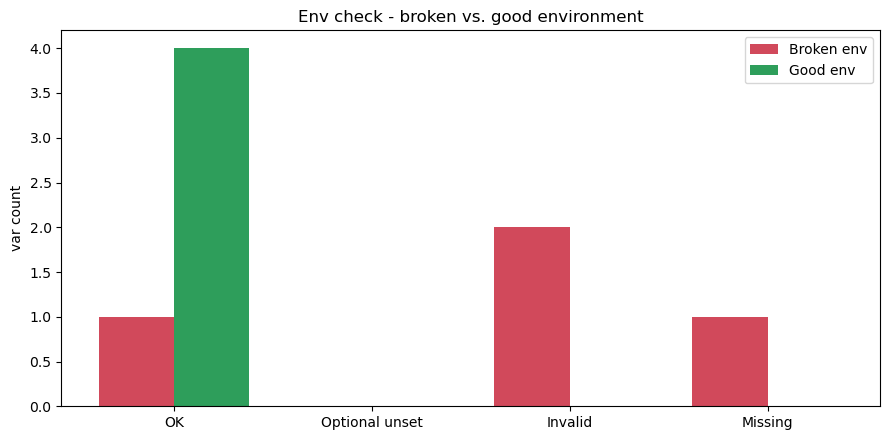

In [5]:
import matplotlib.pyplot as plt
import numpy as np

cats = ["ok", "optional_missing", "invalid", "missing"]
labels = ["OK", "Optional unset", "Invalid", "Missing"]
bad_counts = [len(bad_report[c]) for c in cats]
good_counts = [len(good_report[c]) for c in cats]
colors = ["#2e9e5b", "#9aa0a6", "#e6a700", "#d1495b"]

x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, bad_counts, w, label="Broken env", color="#d1495b")
ax.bar(x + w/2, good_counts, w, label="Good env", color="#2e9e5b")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("var count"); ax.set_title("Env check - broken vs. good environment")
ax.legend(); plt.tight_layout()
plt.savefig("envcheck.png", dpi=150, bbox_inches="tight"); plt.show()

## Summary

- A schema declares **presence + shape** (via regex) for each var.
- The check categorizes every var: ok / optional-unset / invalid / missing.
- `is_passing` is the deploy gate - the CLI maps it to exit code 0/1 so CI blocks bad releases.

This is the engine behind `main.py`.


---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
a 60-day Forward Deployed Engineer portfolio.

**Run it:**
```bash
pip install -r requirements.txt   # stdlib only - nothing to install
python main.py --demo
python main.py --schema .env.schema --env-file .env
```
Wire `python main.py --schema .env.schema` into a CI step or deploy script - a
non-zero exit halts the deploy.
